# S&P 500 — multivariate conventional-methods comparison

The repo's **financial-markets** reference: a head-to-head of conventional
time-series methods on a daily equity index, all reading the **same leak-safe
covariate panel** (VIX, Treasury yields, the 2s10s spread, fed funds, CPI,
unemployment, oil, gold, the dollar index, NASDAQ), plus an LLM-Process
forecaster that can read those covariates in its prompt.

> Given the same macro/market observations, **which method forecasts the index
> best — and can an LLM-Process, handed those covariates, keep up with gradient
> boosting?**

Unlike the energy/oil reference (univariate price trajectory forecast by
news-grounded / code-executing / adaptive **agents**), this is a clean,
reproducible **numerical-methods bake-off across a covariate panel** — no agents,
no news — scored with CRPS and direction metrics.

**Methods**

| Family | Predictors | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | ETS, Kalman, AutoARIMA | — (univariate) |
| ML regression | Darts LinearRegression, LightGBM | ✅ optional past covariates |
| LLM-Process | `SampledTrajectoryLLMPredictor` | ✅ optional covariate prompt blocks |

**How it's organised.** Specs (`specs/*.yaml`) carry only the **experiment
design** — the window and one single-horizon task per `sp500_logret_{N}b` target.
The **predictors and their hyperparameters live in code** (the predictors cell in
Section 4), so you tune models by editing Python, not YAML.

**Workflow:** iterate on the **2025 backtest** (Section 5) by setting
`EXPERIMENT_CONFIG` in the config cell, then spend the **protected 2026 eval**
(Section 7) on your finalists. `"smoke"` is the fast default.

## What's actually forecastable at daily resolution?

- **Target = returns, not the index level.** We forecast **close-to-close
  cumulative log returns** over a few horizons, one series per window:
  `sp500_logret_1b` (next session), `sp500_logret_5b` (forward 1 week),
  `sp500_logret_21b` (forward 1 month). Forecasting `sp500_logret_Nb` exactly `N`
  business days ahead resolves to the **forward** cumulative return over the next
  `N` sessions.
- **Per horizon:** `h=1` → direction / next-day **risk management**; `h=5`/`h=21`
  → tactical rebalancing and option tenors as cumulative returns.
- **The caveat:** for an index the return *level* is close to a martingale, so
  far-ahead point forecasts trend toward ~0; the forecastable, actionable objects
  are **volatility, tail risk, and direction**. That's why a VIX-led panel helps
  most at short horizons — watch the edge shrink as the horizon grows.

## ⚠️ Cutoff-aware evaluation — why the windows are what they are

This is the methodological heart of the comparison, and it's easy to get wrong.

- **Numerical methods are cutoff-safe by construction.** Naive, ETS, Kalman,
  AutoARIMA, LinReg and LightGBM only ever see the series up to the forecast
  origin (`ForecastContext` enforces it). They can be backtested on *any*
  historical window — including the 2020 COVID crash.
- **An LLM is not.** Gemini's training cutoff is ~**January 2025**, so it has
  effectively **memorised** outcomes before then. Scoring an LLM-Process on a
  pre-2025 origin measures *recall*, not forecasting — and silently flatters it
  in the head-to-head, which is exactly the comparison this notebook is about.

So the LLM-inclusive comparison lives **after the cutoff**:

| Window | Spec | Role | LLMP? |
|---|---|---|---|
| **2025** | `sp500_smoke.yaml` / `sp500_backtest_2025.yaml` | open iteration & comparison | ✅ post-cutoff |
| **2026** | `sp500_eval_2026.yaml` | **protected** held-out test (budgeted) | ✅ post-cutoff |
| **2020 COVID** | `sp500_stress_2020.yaml` | volatile-regime stress, **numerical only** | ❌ leaked for LLMs |

This discipline is enforced **in code**: the predictors cell (Section 4) gates the
LLM-Process rows on a `POST_CUTOFF` flag, so selecting `EXPERIMENT_CONFIG =
"stress_2020"` drops them automatically — the numerical methods remain perfectly
valid on that volatile window.

---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`        builds the `DataService` (return targets + the covariate panel).
- `predictors/`    the S&P 500 LLM-Process recipe (prompt framing + sampling budget).
- `leaderboard.py` turns cached results into the `RESULTS_DF` leaderboard frame.
- `analysis.py` / `plots.py`  direction metrics, styled tables, and figures.

We build **one** data service that registers the three return targets plus the
full covariate panel. Target-only predictors simply ignore the registered
covariates; the covariate variants read them.

**First run on the 2025/2026 windows?** Warm the caches to the present first:
`uv run python scripts/fetch_sp500_market.py --refresh` (Yahoo: ^GSPC/^VIX/^IXIC)
and `uv run python scripts/fetch_fred.py` (macro covariates).

In [3]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")


# Resolve the repo root robustly (walk up for the workspace markers) so the
# proxy creds load regardless of the kernel's working directory.
def _repo_root() -> Path:
    here = Path.cwd().resolve()
    for cand in (here, *here.parents):
        if (cand / "pyproject.toml").exists() and (cand / "aieng-forecasting").is_dir():
            return cand
    return here


ROOT = _repo_root()
load_dotenv(ROOT / ".env", override=False)  # LLMP rows call the Vector proxy — need PROXY_* set

from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    MultiTargetEvalSpec,
    cached_multi_backtest,
    describe_spec,
    multi_evaluate,
)
from aieng.forecasting.methods import (
    DartsAutoARIMAPredictor,
    DartsExponentialSmoothingPredictor,
    DartsKalmanForecasterPredictor,
    DartsLightGBMPredictor,
    DartsLinearRegressionPredictor,
    LastValuePredictor,
)
from sp500_forecasting import DEFAULT_COVARIATE_SERIES_IDS, build_sp500_multivariate_service
from sp500_forecasting.leaderboard import build_leaderboard, build_return_compare_frame, build_significance_table
from sp500_forecasting.plots import (
    display_multivariate_backtest_leaderboard,
    plot_return_forecast_vs_actual_multi,
    plot_sp500_log_return_recent,
)
from sp500_forecasting.predictors import build_sp500_llmp_sampled_trajectory


SPECS_DIR = ROOT / "implementations" / "sp500_forecasting" / "specs"
PREDICTIONS_DIR = ROOT / "data" / "predictions"

# Data environment (not part of any single experiment): how far back to load
# price/covariate history, and whether to re-fetch caches from source.
DATA_HISTORY_START = "2016-01-01"
REFRESH_CACHE = False

svc = build_sp500_multivariate_service(
    windows=(1, 5, 21),
    include_covariates=True,
    covariate_series_ids=DEFAULT_COVARIATE_SERIES_IDS,
    start=DATA_HISTORY_START,
    refresh=REFRESH_CACHE,
)

# The covariate panel available to the with-covariates predictors below (an
# optional FRED feed may be skipped, so filter to what actually registered).
registered = set(svc.series_ids)
COVARIATES = [c for c in DEFAULT_COVARIATE_SERIES_IDS if c in registered]
print("targets:", sorted(s for s in registered if s.startswith("sp500_logret_")))
print(f"covariates registered: {len(COVARIATES)} / {len(DEFAULT_COVARIATE_SERIES_IDS)} requested")

ImportError: cannot import name 'build_significance_table' from 'sp500_forecasting.leaderboard' (/home/coder/agentic-forecasting/implementations/sp500_forecasting/leaderboard.py)

---
## 2. Configuration

One selector picks the backtest window; everything downstream adapts. Specs are
the source of truth for the **window and tasks** — not the predictors.

In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# EXPERIMENT_CONFIG chooses which window drives the backtest (Section 5); all
# downstream cells adapt. The protected 2026 eval (Section 7) is fixed.
#
#   "smoke"          short late-2025 window (~6 weekly origins), post-cutoff.
#                    Fast default; LLM-Process predictors ON.
#   "backtest_2025"  weekly origins across all of 2025 (~50), post-cutoff.
#                    The full comparison; LLMP is slow here — trim the roster.
#   "stress_2020"    the COVID crash (daily origins Feb–Apr 2020). NUMERICAL
#                    ONLY — pre-cutoff is leaked for LLMs, so the predictors cell
#                    drops the LLMP rows for this config.

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "sp500_smoke.yaml",
    "backtest_2025": "sp500_backtest_2025.yaml",
    "stress_2020": "sp500_stress_2020.yaml",
}
_EVAL_SPEC_FILE = "sp500_eval_2026.yaml"

# 2020 is pre-cutoff → keep the LLM-Process out of the comparison (see Section 0).
POST_CUTOFF = EXPERIMENT_CONFIG in {"smoke", "backtest_2025"}

with (SPECS_DIR / _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(
    f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]}  "
    f"(LLMP {'on' if POST_CUTOFF else 'OFF — pre-cutoff'})"
)
print(describe_spec(backtest_spec, data_service=svc))

Config: 'smoke'  →  sp500_smoke.yaml  (LLMP on)
MultiTargetBacktestSpec (spec_id=sp500_smoke)
  description: Smoke multivariate demo: weekly origins in late 2025 (post-cutoff), forecasting close-to-close cumulative returns at 1/5/21 business days.
  start:       2025-10-06 00:00:00
  end:         2025-11-14 00:00:00
  stride:      5
  warmup:      250
  tasks:       3

Task: sp500_logret_1b
  description: S&P 500 close-to-close cumulative log return, 1 business day ahead (next-session return / direction).
  horizons:    1
  frequency:   B
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: sp500_logret_1b
    description:    S&P 500 close-to-close cumulative log return over 1 business day(s) (next-session) (Yahoo Finance ^GSPC, derived)
    source:         Yahoo Finance (^GSPC), derived
    units:          log-return
    frequency:      B

Task: sp500_logret_5b
  description: S&P 500 close-to-close cumulative log return, 5 business days a

---
## 3. Target context — observed returns

The most recent realised next-session returns (the `h=1` target). Blue = index up
over the window, red = down.

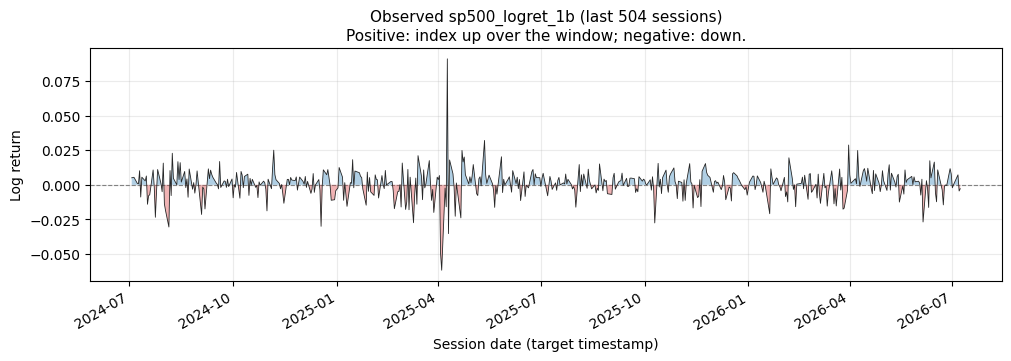

In [3]:
fig, _ = plot_sp500_log_return_recent(svc, n_trading_days=504)
plt.show()

---
## 4. Predictors — configured in code

This is where you choose the roster. Each predictor implements the same
`Predictor` API against the loaded spec; the conventional methods come straight
from `aieng.forecasting.methods`, and the LLM-Process variants come from the
S&P 500 recipe in `predictors/`. The covariate variants read the registered
`COVARIATES` panel; the target-only variants pass `covariate_series_ids=None`.

| Group | Predictor | Covariates? |
|---|---|---|
| Naive floor | `LastValuePredictor` | — |
| Classical | `DartsExponentialSmoothingPredictor` (ETS), `DartsKalmanForecasterPredictor` | — |
| ML regression | `DartsLinearRegressionPredictor`, `DartsLightGBMPredictor` | target-only **and** + panel |
| LLM-Process | `build_sp500_llmp_sampled_trajectory` | target-only **and** + panel (post-cutoff only) |

`AutoARIMA` is left commented (accurate but slow); add it back for a classical
sweep. The `LLMP (target)` vs `LLMP + cov` pair is the centerpiece — its CRPS gap
answers whether an LLM can use the same exogenous panel the ML methods do.

In [4]:
# Shared hyperparameters for the Darts regression models.
LAGS = 5  # autoregressive lags (and past-covariate lags) for the regression models
NUM_SAMPLES = 100  # empirical-quantile sample count for the probabilistic Darts models
LGBM_KWARGS = {"num_threads": 1, "n_jobs": 1, "verbosity": -1}

# ── Naive floor + classical (univariate) ──────────────────────────────────────
naive = LastValuePredictor()
ets = DartsExponentialSmoothingPredictor(num_samples=NUM_SAMPLES)
kalman = DartsKalmanForecasterPredictor(num_samples=NUM_SAMPLES)
autoarima = DartsAutoARIMAPredictor(num_samples=NUM_SAMPLES)  # accurate but the slowest classical method

# ── ML regression — target-only vs the covariate panel ────────────────────────
linreg = DartsLinearRegressionPredictor(lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES)
linreg_cov = DartsLinearRegressionPredictor(
    lags=LAGS, lags_past_covariates=LAGS, covariate_series_ids=COVARIATES, num_samples=NUM_SAMPLES
)
lightgbm = DartsLightGBMPredictor(
    lags=LAGS, covariate_series_ids=None, num_samples=NUM_SAMPLES, lgbm_kwargs=LGBM_KWARGS
)
lightgbm_cov = DartsLightGBMPredictor(
    lags=LAGS,
    lags_past_covariates=LAGS,
    covariate_series_ids=COVARIATES,
    num_samples=NUM_SAMPLES,
    lgbm_kwargs=LGBM_KWARGS,
)

all_predictors = [naive, ets, kalman, autoarima, linreg, linreg_cov, lightgbm, lightgbm_cov]

# Which covariate panel each predictor consumes — drives the leaderboard's
# covariate columns. Predictors absent from this map are treated as target-only.
PREDICTOR_COVARIATES = {
    linreg_cov.predictor_id: COVARIATES,
    lightgbm_cov.predictor_id: COVARIATES,
}
# Short labels for the leaderboard "model" column and the CRPS charts.
PREDICTOR_LABELS = {
    naive.predictor_id: "Naive",
    ets.predictor_id: "ETS",
    kalman.predictor_id: "Kalman",
    autoarima.predictor_id: "AutoARIMA",
    linreg.predictor_id: "LinReg",
    linreg_cov.predictor_id: "LinReg + cov",
    lightgbm.predictor_id: "LightGBM",
    lightgbm_cov.predictor_id: "LightGBM + cov",
}

# ── LLM-Process (sampled trajectories) — target-only vs with-covariates ────────
# Gated on POST_CUTOFF: the 2020 stress window is pre-cutoff and leaked for LLMs,
# so we keep the LLMP rows out of that comparison entirely. The recipe (prompt
# framing, defaults) lives in predictors/llmp_sampled_trajectory.py; tune it
# there, or override model= / n_samples= / history_window= per call here.
if POST_CUTOFF:
    llmp = build_sp500_llmp_sampled_trajectory(n_samples=8, history_window=48)
    llmp_cov = build_sp500_llmp_sampled_trajectory(n_samples=8, history_window=48, covariate_series_ids=COVARIATES)
    all_predictors += [llmp, llmp_cov]
    PREDICTOR_COVARIATES[llmp_cov.predictor_id] = COVARIATES
    PREDICTOR_LABELS[llmp.predictor_id] = "LLMP (target)"
    PREDICTOR_LABELS[llmp_cov.predictor_id] = "LLMP + cov"

print(f"{len(all_predictors)} predictors configured (LLMP {'on' if POST_CUTOFF else 'off'}):")
for p in all_predictors:
    print(f"  {p.predictor_id}")

10 predictors configured (LLMP on):
  last_value_naive
  darts_ets
  darts_kalman
  darts_autoarima
  darts_linreg
  darts_linreg_cov
  darts_lightgbm
  darts_lightgbm_cov
  llmp_sampled_trajectories_sp500_v1_target_h48_n8[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_sp500_v1_cov_h48_n8[gemini-3.1-flash-lite-preview]


---
## 5. 2025 backtest — the comparison (post-cutoff)

`cached_multi_backtest` runs each predictor across the three single-horizon tasks
and writes every `BacktestResult` to `data/predictions/<spec_id>/` — so a re-run
is free from cache (pass `force_refresh=True` to recompute). The loop prints each
task's mean CRPS as it lands.

In [ ]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  ({len(result.predictions)} preds)")

RESULTS_DF = build_leaderboard(
    results_by_predictor,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Running last_value_naive ...
  sp500_logret_1b     mean CRPS = 0.01196  (6 preds)
  sp500_logret_5b     mean CRPS = 0.01721  (6 preds)
  sp500_logret_21b    mean CRPS = 0.02964  (6 preds)
Running darts_ets ...
  sp500_logret_1b     mean CRPS = 0.00400  (6 preds)
  sp500_logret_5b     mean CRPS = 0.01285  (6 preds)
  sp500_logret_21b    mean CRPS = 0.02219  (6 preds)
Running darts_kalman ...
  sp500_logret_1b     mean CRPS = 0.00384  (6 preds)
  sp500_logret_5b     mean CRPS = 0.00920  (6 preds)
  sp500_logret_21b    mean CRPS = 0.01009  (6 preds)
Running darts_autoarima ...
  sp500_logret_1b     mean CRPS = 0.00395  (6 preds)
  sp500_logret_5b     mean CRPS = 0.00992  (6 preds)
  sp500_logret_21b    mean CRPS = 0.01469  (6 preds)
Running darts_linreg ...


### Leaderboard — mean CRPS by method and horizon

Read it as a story: the spread between methods (and the naive floor's
disadvantage) is widest at `h=1` and compresses by `h=21`. The `dir_*` columns
report next-direction skill (most meaningful at `h=1`).

,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval
0,1,sp500_logret_1b,LinReg + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_linreg_cov,0.00347,6,6,0,0.500,1.000,0.667,0.500,0.333,6
1,1,sp500_logret_1b,LLMP (target),False,0,—,llmp_sampled_trajectories_sp500_v1_target_h48_n8[gemini-3.1-flash-lite-preview],0.00360,6,6,0,0.000,0.000,0.000,0.500,0.500,6
2,1,sp500_logret_1b,LinReg,False,0,—,darts_linreg,0.00362,6,6,0,0.250,0.333,0.286,0.167,0.111,6
3,1,sp500_logret_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.00367,6,6,0,0.500,0.667,0.571,0.500,0.556,6
4,1,sp500_logret_1b,Kalman,False,0,—,darts_kalman,0.00378,6,6,0,0.333,0.333,0.333,0.333,0.556,6
5,1,sp500_logret_1b,LLMP + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",llmp_sampled_trajectories_sp500_v1_cov_h48_n8[gemini-3.1-flash-lite-preview],0.00383,6,6,0,0.000,0.000,0.000,0.500,0.167,6
6,1,sp500_logret_1b,LightGBM,False,0,—,darts_lightgbm,0.00399,6,6,0,0.500,0.667,0.571,0.500,0.556,6
7,1,sp500_logret_1b,ETS,False,0,—,darts_ets,0.00409,6,6,0,0.500,0.667,0.571,0.500,0.444,6
8,1,sp500_logret_1b,AutoARIMA,False,0,—,darts_autoarima,0.00427,6,6,0,0.333,0.333,0.333,0.333,0.333,6
9,1,sp500_logret_1b,Naive,False,0,—,last_value_naive,0.01196,6,6,0,0.500,1.000,0.667,0.500,0.500,6


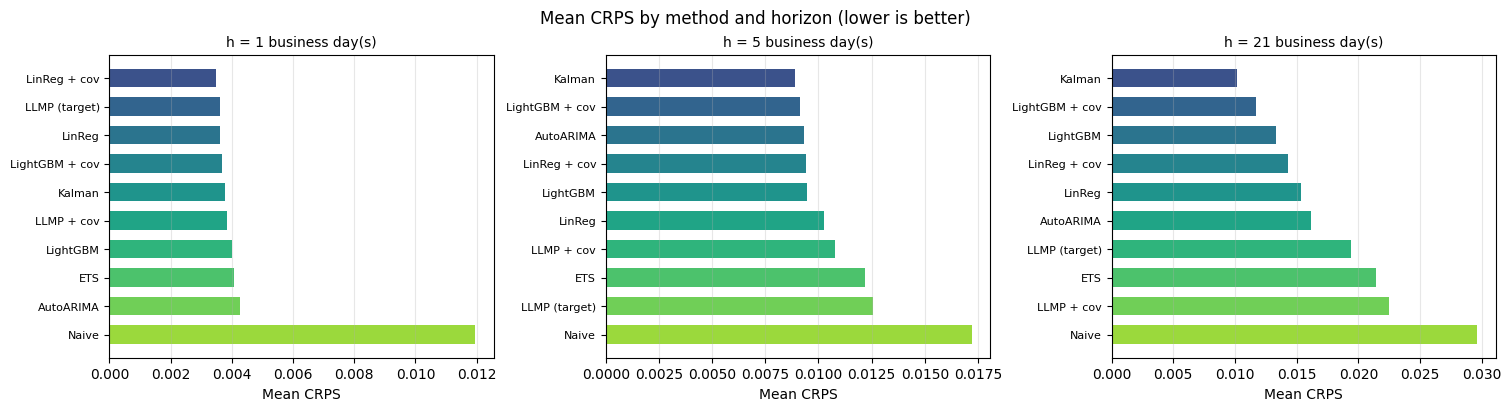

In [ ]:
display_multivariate_backtest_leaderboard(RESULTS_DF)

### Statistical significance — Diebold-Mariano vs the naive floor

Mean CRPS alone doesn't say whether a gap is real or noise over only a handful
of origins. `build_significance_table` runs a Diebold-Mariano test — via
`aieng.forecasting.evaluation.compare_multi` (the `comparison` extra,
`macroforecast.tests.dm_test` under the hood) — for every predictor against the
**naive floor**, per horizon. A negative `dm_statistic` means the naive floor
had the higher (worse) CRPS; `significant` flags `dm_p_value < 0.05`.

With only ~6 origins in the `smoke` window this is underpowered — treat it as a
sanity check, not a verdict. Re-run with `EXPERIMENT_CONFIG = "backtest_2025"`
(≈50 weekly origins) for a test with real statistical power.

In [ ]:
SIG_DF = build_significance_table(
    results_by_predictor,
    benchmark_predictor_id=naive.predictor_id,
    labels_by_predictor=PREDICTOR_LABELS,
)
SIG_DF.style.format({"dm_statistic": "{:.3f}", "dm_p_value": "{:.4f}"})

### Reading the LLMP ± covariates rows

When the LLM-Process rows are present (post-cutoff windows), compare them directly:
- **LLMP (target)** — the LLM sees **only** the return history.
- **LLMP + cov** — it additionally sees **labeled covariate-history blocks**
  (VIX, yields, …) in its prompt.

Their CRPS gap answers the headline question: does the same exogenous panel the
ML methods use help an LLM — and does either LLMP variant reach the
gradient-boosting rows? Because these windows are **post-cutoff**, the LLM can't
be reciting memorised outcomes.

---
## 6. Forecast vs realised (next session, h=1)

A few models' median next-session forecast against the realised return (percent)
— the near-zero, low-amplitude forecasts vs the noisy realised series are the
daily-efficiency story made visual. These reuse the cached `h=1` predictions from
Section 5 (no re-running).

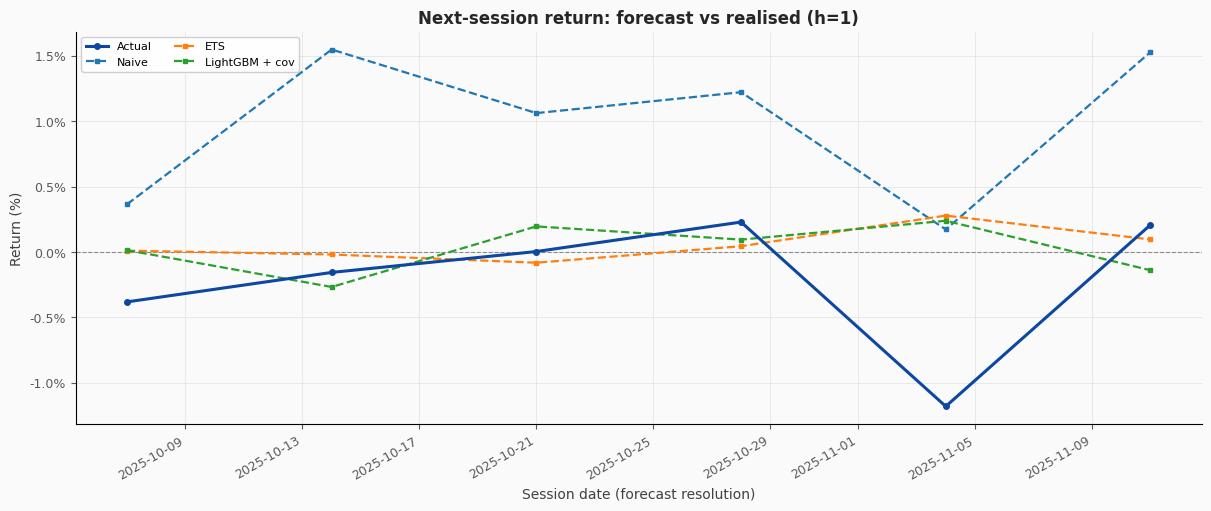

In [ ]:
# A few representative models, pulled straight from the cached backtest results.
H1_TASK = "sp500_logret_1b"
demo_ids = [naive.predictor_id, ets.predictor_id, lightgbm_cov.predictor_id]

compare_by_run: dict[str, pd.DataFrame] = {}
for pid in demo_ids:
    result = results_by_predictor.get(pid, {}).get(H1_TASK)
    if result is None:
        continue
    label = PREDICTOR_LABELS.get(pid, pid)
    compare_by_run[label] = build_return_compare_frame(result.predictions, svc, H1_TASK)

fig, _ = plot_return_forecast_vs_actual_multi(compare_by_run, title="Next-session return: forecast vs realised (h=1)")
plt.show()

---
## 7. Protected 2026 eval — the honest scoreboard

`multi_evaluate()` against the held-out 2026 window. This is **scarce**:
`sp500_eval_2026.yaml` carries `max_runs`, and one `multi_evaluate` call across
all three horizons counts as **one** run. Pass an `EvalTracker` to enforce that
budget across sessions (commented below — it would block re-runs once exhausted,
so we leave it off here and just show `run_number`).

Spend it on the models you committed to from the 2025 backtest — pick a small
**finalists** list in the cell below, not the whole roster. Eval results are
never cached (caching would obscure the budget), so each run recomputes.

> **Runtime:** the finalists default to the cutoff-safe baselines plus
> `LightGBM + cov`. Add the LLMP variants when you're ready to spend the proxy
> tokens on the protected scoreboard (each LLMP eval is ~8 origins × 3 horizons ×
> `n_samples` calls).

In [ ]:
# from aieng.forecasting.evaluation import EvalTracker
# tracker = EvalTracker(ROOT / "data" / "sp500_eval_runs.yaml")  # enforces max_runs across sessions

with (SPECS_DIR / _EVAL_SPEC_FILE).open() as f:
    eval_spec = MultiTargetEvalSpec.model_validate(yaml.safe_load(f))

# Finalists only — the held-out window is scarce. Pick the handful you committed
# to from the 2025 backtest (e.g. add `llmp`, `llmp_cov` here when ready to spend
# the proxy tokens — they exist only when POST_CUTOFF).
eval_finalists = [naive, lightgbm_cov]

eval_results: dict[str, dict[str, object]] = {}
for predictor in eval_finalists:
    print(f"Evaluating {predictor.predictor_id} ...", flush=True)
    eval_results[predictor.predictor_id] = multi_evaluate(
        predictor=predictor,
        spec=eval_spec,
        data_service=svc,
        tracker=None,  # set to `tracker` above to enforce the max_runs budget
    )
    for task_id, result in eval_results[predictor.predictor_id].items():
        print(f"  {task_id:18s}  mean CRPS = {result.mean_score:.5f}  (run #{result.run_number})")

EVAL_DF = build_leaderboard(
    eval_results,
    svc,
    covariates_by_predictor=PREDICTOR_COVARIATES,
    labels_by_predictor=PREDICTOR_LABELS,
)

Evaluating last_value_naive ...
  sp500_logret_1b     mean CRPS = 0.01043  (run #1)
  sp500_logret_5b     mean CRPS = 0.00984  (run #1)
  sp500_logret_21b    mean CRPS = 0.04483  (run #1)
Evaluating darts_lightgbm_cov ...
  sp500_logret_1b     mean CRPS = 0.00442  (run #1)
  sp500_logret_5b     mean CRPS = 0.01295  (run #1)
  sp500_logret_21b    mean CRPS = 0.03798  (run #1)


,horizon,target,model,uses_covariates,n_covariates,covariates,predictor_id,mean_crps,n_scores,n_predictions,skipped_origins,dir_precision_up,dir_recall_up,dir_f1_up,dir_accuracy,dir_roc_auc_prob_up,dir_n_eval,run_number
0,1,sp500_logret_1b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.00442,8,8,0,0.200,0.333,0.250,0.250,0.267,8,1
1,1,sp500_logret_1b,Naive,False,0,—,last_value_naive,0.01043,8,8,0,0.286,0.667,0.400,0.250,0.333,8,1
2,5,sp500_logret_5b,Naive,False,0,—,last_value_naive,0.00984,7,7,1,0.333,0.500,0.400,0.571,0.550,7,1
3,5,sp500_logret_5b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.01295,7,7,1,0.333,1.000,0.500,0.429,0.500,7,1
4,21,sp500_logret_21b,LightGBM + cov,True,10,"vix_level_l1b, vix_log_ret_1b_l1b, ust10y_level_l1b, ust2y10y_spread_l1b, fed_funds_level_l1b, cpi_mom_logdiff_l1b, unemployment_rate_l1b, oil_log_ret_1b_l1b, dollar_index_log_ret_1b_l1b, nasdaq_log_ret_1b_l1b",darts_lightgbm_cov,0.03798,8,8,0,0.250,1.000,0.400,0.250,0.250,8,1
5,21,sp500_logret_21b,Naive,False,0,—,last_value_naive,0.04483,8,8,0,0.000,0.000,0.000,0.500,0.333,8,1


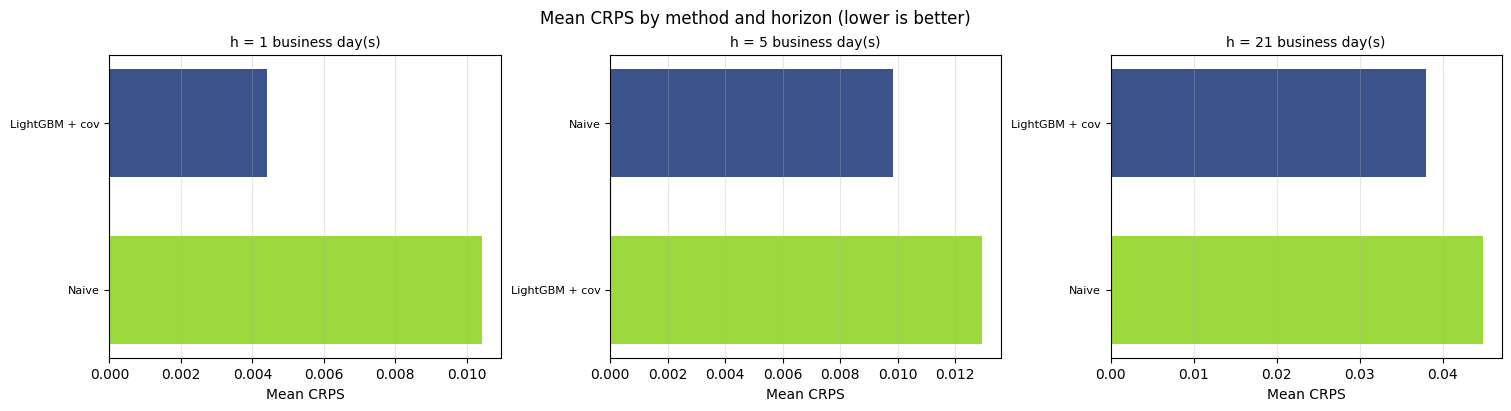

In [ ]:
display_multivariate_backtest_leaderboard(EVAL_DF)

### Statistical significance — protected 2026 eval

Same Diebold-Mariano test as Section 5, run on the protected eval results. This
is the honest scoreboard — spend it on the finalists you've already committed
to; `naive` must stay in `eval_finalists` above to serve as the benchmark.

In [ ]:
EVAL_SIG_DF = build_significance_table(
    eval_results,
    benchmark_predictor_id=naive.predictor_id,
    labels_by_predictor=PREDICTOR_LABELS,
)
EVAL_SIG_DF.style.format({"dm_statistic": "{:.3f}", "dm_p_value": "{:.4f}"})

---
## Where to go next

- **Scale up the backtest.** Set `EXPERIMENT_CONFIG = "backtest_2025"` (weekly
  origins across all of 2025, full panel) and re-run from Section 2. The LLMP rows
  are slow over ~50 origins — trim `all_predictors` or widen the spec's `stride`.
- **Study the COVID regime (numerical only).** Set
  `EXPERIMENT_CONFIG = "stress_2020"`: a volatile window where a covariate edge is
  most visible. The predictors cell drops the LLMP rows automatically (2020 is
  pre-cutoff, so an LLM would be reciting, not forecasting).
- **Add a method.** Instantiate any `Predictor` (e.g. another Darts model — mirror
  `aieng/forecasting/methods/numerical/darts_classical.py`) in the predictors
  cell and append it to `all_predictors` with a `PREDICTOR_LABELS` entry. No
  registry or dispatch to edit.
- **Tune the LLM-Process.** Edit `predictors/llmp_sampled_trajectory.py` (prompt
  framing, history window) or pass a different `model=` / `n_samples=` in the
  predictors cell. How do the results move?
- **Try an agentic forecaster** with the same cutoff caveats as the LLMP. Do
  agents add lift over LLMPs or the conventional methods?
- **Spend the eval honestly.** Wire the `EvalTracker` in Section 7 so `max_runs`
  is enforced, and only evaluate models you've committed to.